In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("camaugweather.csv")

print (data.head())


                  time  temp  dwpt  rhum  prcp  snow  wdir  wspd  wpgt  \
0  2026-08-08 00:00:00  17.1  10.2    64   0.0   NaN   113   9.4   NaN   
1  2026-08-08 01:00:00  16.3  11.7    74   0.0   NaN   124   8.3   NaN   
2  2026-08-08 02:00:00  15.3  11.9    80   0.0   NaN   133   8.6   NaN   
3  2026-08-08 03:00:00  14.5  11.1    80   0.0   NaN   149   8.3   NaN   
4  2026-08-08 04:00:00  13.7  10.1    79   0.0   NaN   164   8.6   NaN   

     pres  tsun  coco  
0  1021.9   NaN     1  
1  1021.8   NaN     1  
2  1021.6   NaN     1  
3  1021.3   NaN     1  
4  1021.2   NaN     1  


In [68]:
data["time"] = pd.to_datetime(data["time"])

data["x"] = (data["time"] - data["time"].min()).dt.total_seconds() / 86400

In [69]:
y = data["temp"]

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)

gpr.fit(data[["x"]], y)

print (gpr.kernel_)



15.9**2 * RBF(length_scale=0.206) + WhiteKernel(noise_level=0.206)


Learned kernel:
0.551**2 * RBF(length_scale=0.169) + 0.937**2 * ExpSineSquared(length_scale=1.38, periodicity=1) + WhiteKernel(noise_level=0.00872)


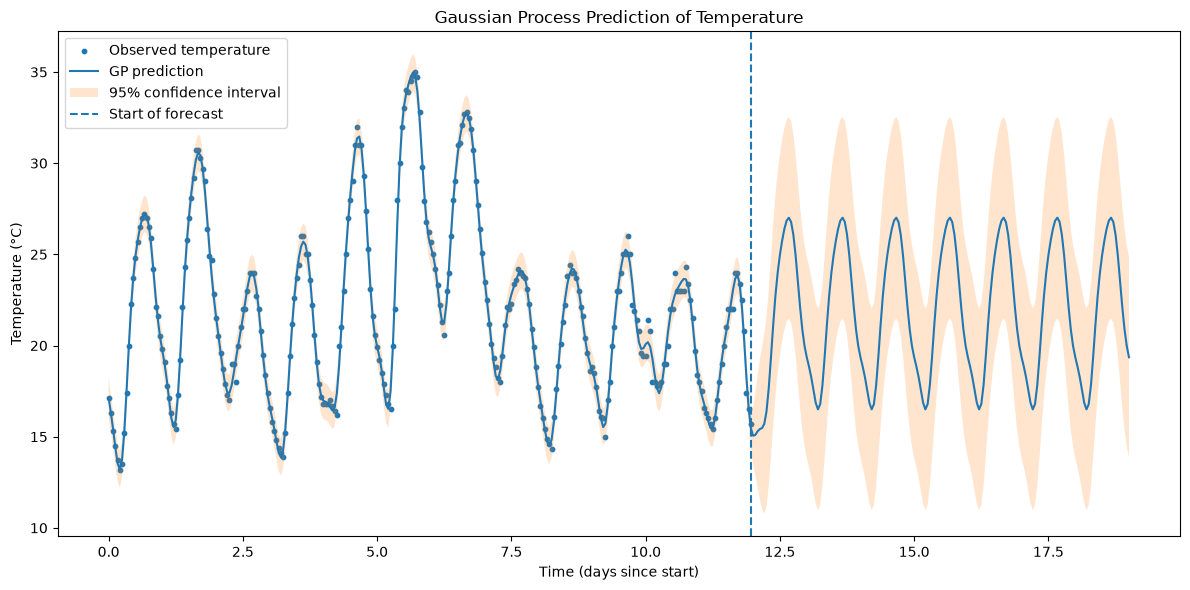

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ExpSineSquared,
    RationalQuadratic,
    WhiteKernel
)

# --------------------------------------------------
# 1. Load the weather data
# --------------------------------------------------

df = pd.read_csv("camaugweather.csv")

# Convert the time column to datetime
df["time"] = pd.to_datetime(df["time"])

# Remove rows where temperature is missing
df = df.dropna(subset=["temp"])

# --------------------------------------------------
# 2. Convert time into ONE numerical variable
#    x = days since the first observation
# --------------------------------------------------

df["x"] = (
    (df["time"] - df["time"].min())
    .dt.total_seconds()
    / 86400
)

X = df["x"].values.reshape(-1, 1)
y = df["temp"].values

# --------------------------------------------------
# 3. Create a kernel
# --------------------------------------------------

kernel = (
    10.0**2 * RBF(length_scale=2.0)
    + 5.0**2 * ExpSineSquared(
       periodicity=1.0,
       length_scale=5.0,
       periodicity_bounds="fixed"
    
    )
    + WhiteKernel(noise_level=1.0)
)

# --------------------------------------------------
# 4. Create and fit the Gaussian Process
# --------------------------------------------------

gaussian_process = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=9
)

gaussian_process.fit(X, y)

print("Learned kernel:")
print(gaussian_process.kernel_)

# --------------------------------------------------
# 5. Create x values covering:
#    - your original data
#    - the next 7 days
# --------------------------------------------------

x_max = df["x"].max()

# 7 days = 168 hours
x_future = np.arange(
    x_max + 1/24,
    x_max + 7 + 1/24,
    1/24
)

# Combine original and future x values
X_plot = np.concatenate([
    X[:, 0],
    x_future
])

X_plot = np.sort(X_plot).reshape(-1, 1)

# --------------------------------------------------
# 6. Predict
# --------------------------------------------------

y_pred, y_std = gaussian_process.predict(
    X_plot,
    return_std=True
)

# --------------------------------------------------
# 7. Plot the results
# --------------------------------------------------

plt.figure(figsize=(12, 6))

# Actual observations
plt.scatter(
    X[:, 0],
    y,
    s=10,
    label="Observed temperature"
)

# GP prediction
plt.plot(
    X_plot[:, 0],
    y_pred,
    label="GP prediction"
)

# Uncertainty
plt.fill_between(
    X_plot[:, 0],
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    alpha=0.2,
    label="95% confidence interval"
)

# Mark where the forecast starts
plt.axvline(
    x=x_max,
    linestyle="--",
    label="Start of forecast"
)

plt.xlabel("Time (days since start)")
plt.ylabel("Temperature (°C)")
plt.title("Gaussian Process Prediction of Temperature")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
day_19 = np.array([[19.0]])

temperature, uncertainty = gaussian_process.predict(
    day_19,
    return_std=True
)

print(f"Predicted temperature on day 19: {temperature[0]:.2f} °C")
print(f"Uncertainty: ±{uncertainty[0]:.2f} °C")
print(
    f"95% interval: "
    f"{temperature[0] - 1.96 * uncertainty[0]:.2f} to "
    f"{temperature[0] + 1.96 * uncertainty[0]:.2f} °C"
)

Predicted temperature on day 19: 19.36 °C
Uncertainty: ±2.81 °C
95% interval: 13.84 to 24.87 °C


In [72]:
day_19_times = np.linspace(25, 26, 24 * 4).reshape(-1, 1)

temperatures, uncertainties = gaussian_process.predict(
    day_19_times,
    return_std=True
)

highest_index = np.argmax(temperatures)

print(f"Predicted high: {temperatures[highest_index]:.2f} °C")
print(f"Approximate time: {day_19_times[highest_index, 0] - 25:.2f} days after midnight")
print(f"Uncertainty: ±{uncertainties[highest_index]:.2f} °C")

Predicted high: 27.01 °C
Approximate time: 0.66 days after midnight
Uncertainty: ±2.82 °C


In [73]:
target_time = pd.Timestamp("2024-08-27 14:55")

x_target = (
    target_time - df["time"].min()
).total_seconds() / 86400

temperature, uncertainty = gaussian_process.predict(
    np.array([[x_target]]),
    return_std=True
)

print(f"Predicted temperature: {temperature[0]:.2f} °C")
print(f"Uncertainty: ±{uncertainty[0]:.2f} °C")

Predicted temperature: 26.82 °C
Uncertainty: ±2.82 °C
